# TSP - Comparación de Algoritmos Metaheurísticos y Exactos

Este notebook compara diferentes algoritmos para resolver el Problema del Agente Viajero (TSP):
- **Algoritmo Genético (AG)**: Metaheurística evolutiva
- **Optimización por Colonia de Hormigas (ACO)**: Metaheurística basada en comportamiento de hormigas
- **Programación Lineal DFJ**: Método iterativo con eliminación de subtours
- **Programación Lineal MTZ**: Método exacto que garantiza el óptimo global

## Configuración inicial y directorios

In [1]:
import os
import pandas as pd
import numpy as np
import folium
from geopy.distance import geodesic
import pulp
import matplotlib.pyplot as plt
import random
import time

# Crear directorios para salidas si no existen
os.makedirs('maps', exist_ok=True)
os.makedirs('reports', exist_ok=True)
os.makedirs('graphs', exist_ok=True)

print("✓ Librerías importadas")
print("✓ Directorios creados: maps/, reports/, graphs/")

✓ Librerías importadas
✓ Directorios creados: maps/, reports/, graphs/


## Funciones auxiliares

In [2]:
def construir_grafo_completo(ruta_csv_procesado, n_nodos, semilla):
    """Genera un grafo completo de n nodos desde el CSV de direcciones."""
    df = pd.read_csv(ruta_csv_procesado)
    
    if n_nodos > len(df):
        n_nodos = len(df)
        
    df_random = df.sample(n=n_nodos, random_state=semilla).reset_index(drop=True)

    info_nodos = {}
    coords_list = [] 
    
    for id_nodo, row in df_random.iterrows():
        coords_list.append((id_nodo, row['latitud'], row['longitud']))
        direccion_texto = f"{row.get('Calle', '')} {row.get('# de casa', '')}, {row.get('colonia', '')}"
        
        info_nodos[id_nodo] = {
            'lat': row['latitud'],
            'lon': row['longitud'],
            'nombre': direccion_texto,
            'id_original_excel': row.get('id_original_excel', 'N/A')
        }

    from itertools import combinations
    grafo_distancias = {}
    for (id1, lat1, lon1), (id2, lat2, lon2) in combinations(coords_list, 2):
        dist = geodesic((lat1, lon1), (lat2, lon2)).kilometers
        grafo_distancias[(id1, id2)] = round(dist, 4)
        
    return grafo_distancias, info_nodos


def procesar_grafo_separado(diccionario_original):
    """Convierte el formato de experimento a lista de adyacencia."""
    datos_nodos = diccionario_original.get('info_nodos', {})
    lista_adyacencia = {nodo_id: [] for nodo_id in datos_nodos}
    
    distancias = diccionario_original.get('distancias', {})
    
    for (nodo_a, nodo_b), distancia in distancias.items():
        lista_adyacencia[nodo_a].append((nodo_b, distancia))
        lista_adyacencia[nodo_b].append((nodo_a, distancia))
        
    return lista_adyacencia, datos_nodos

## Clases de algoritmos

In [3]:
class GA_TSP:
    """Algoritmo Genético para TSP con Edge Recombination Crossover"""
    def __init__(self, lista_adyacencia, datos_nodos, tam_poblacion=100, prob_cruce=0.8, prob_mutacion=0.01, n_generaciones=300):
        self.lista_adyacencia = lista_adyacencia
        self.datos_nodos = datos_nodos
        self.tam_poblacion = tam_poblacion
        self.prob_cruce = prob_cruce
        self.prob_mutacion = prob_mutacion
        self.n_generaciones = n_generaciones
        self.poblacion = []
        self.mejor_ruta = None
        self.mejor_costo = float('inf')
    
    def inicializar_poblacion(self):
        nodos = list(self.lista_adyacencia.keys())
        for _ in range(self.tam_poblacion):
            ruta = nodos[:]
            random.shuffle(ruta)
            self.poblacion.append(ruta)
    
    def calcular_costo(self, ruta):
        costo = 0
        for i in range(len(ruta)):
            nodo_actual = ruta[i]
            nodo_siguiente = ruta[(i + 1) % len(ruta)]
            for vecino, distancia in self.lista_adyacencia[nodo_actual]:
                if vecino == nodo_siguiente:
                    costo += distancia
                    break
        return costo
    
    def seleccionar_padres(self, k=2):
        torneo1 = random.sample(self.poblacion, k)
        padre1 = sorted(torneo1, key=self.calcular_costo)[0]
        torneo2 = random.sample(self.poblacion, k)
        padre2 = sorted(torneo2, key=self.calcular_costo)[0]
        return padre1, padre2
    
    def cruzar(self, padre1, padre2):
        """Edge Recombination Crossover (ERX)"""
        adj = {gene: set() for gene in padre1}
        n = len(padre1)
        
        def agregar_vecinos(p):
            for i in range(n):
                gene = p[i]
                izq = p[i - 1]
                der = p[(i + 1) % n]
                adj[gene].add(izq)
                adj[gene].add(der)
        
        agregar_vecinos(padre1)
        agregar_vecinos(padre2)
        
        hijo = []
        actual = random.choice(padre1)
        hijo.append(actual)
        
        for vecinos in adj.values():
            vecinos.discard(actual)
        
        while len(hijo) < n:
            vecinos_actual = adj[actual]
            
            if vecinos_actual:
                siguiente = min(vecinos_actual, key=lambda x: len(adj[x]))
            else:
                restantes = [g for g in padre1 if g not in hijo]
                siguiente = random.choice(restantes)
            
            hijo.append(siguiente)
            
            for v in adj.values():
                v.discard(siguiente)
            
            actual = siguiente
        
        return hijo
    
    def mutar(self, ruta):
        if random.random() < self.prob_mutacion:
            i, j = random.sample(range(len(ruta)), 2)
            ruta[i], ruta[j] = ruta[j], ruta[i]
        return ruta
    
    def ejecutar(self):
        self.inicializar_poblacion()
        hist_mejor = []
        hist_promedio = []
        
        for gen in range(self.n_generaciones):
            nueva_poblacion = []
            
            for _ in range(self.tam_poblacion):
                padre1, padre2 = self.seleccionar_padres()
                
                if random.random() < self.prob_cruce:
                    hijo = self.cruzar(padre1, padre2)
                else:
                    hijo = padre1[:]
                
                hijo = self.mutar(hijo)
                nueva_poblacion.append(hijo)
            
            poblacion_extendida = self.poblacion + nueva_poblacion
            poblacion_extendida.sort(key=self.calcular_costo)
            self.poblacion = poblacion_extendida[:self.tam_poblacion]
            
            costos = [self.calcular_costo(ind) for ind in self.poblacion]
            mejor = min(costos)
            promedio = sum(costos) / len(costos)
            
            hist_mejor.append(mejor)
            hist_promedio.append(promedio)
            
            if mejor < self.mejor_costo:
                self.mejor_costo = mejor
                idx = costos.index(mejor)
                self.mejor_ruta = self.poblacion[idx][:]
        
        return self.mejor_ruta, hist_mejor, hist_promedio

In [4]:
class ACO_TSP:
    """Algoritmo de Colonia de Hormigas para TSP"""
    def __init__(self, lista_adyacencia, datos_nodos, n_hormigas=50, n_iteraciones=100, 
                 feromona_inicial=1.0, Q=1.0, alpha=1.0, beta=2.0, rho=0.5):
        self.lista_adyacencia = lista_adyacencia
        self.datos_nodos = datos_nodos
        self.n_hormigas = n_hormigas
        self.n_iteraciones = n_iteraciones
        self.feromona_inicial = feromona_inicial
        self.Q = Q
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        
        self.nodos_list = list(datos_nodos.keys())
        self.n_nodos = len(self.nodos_list)
        self.id_to_idx = {nodo_id: idx for idx, nodo_id in enumerate(self.nodos_list)}
        self.idx_to_id = {idx: nodo_id for nodo_id, idx in self.id_to_idx.items()}
        
        self.feromonas = None
        self.heuristica = None
        self.mejor_ruta = None
        self.mejor_costo = float('inf')
        
    def inicializar_feromonas(self):
        self.feromonas = np.full((self.n_nodos, self.n_nodos), self.feromona_inicial)
        
    def calcular_heuristica(self):
        self.heuristica = np.zeros((self.n_nodos, self.n_nodos))
        epsilon = 0.0001
        
        for nodo_id, vecinos in self.lista_adyacencia.items():
            idx_i = self.id_to_idx[nodo_id]
            for vecino_id, distancia in vecinos:
                idx_j = self.id_to_idx[vecino_id]
                if distancia <= 0:
                    distancia = epsilon
                self.heuristica[idx_i, idx_j] = 1.0 / distancia
                
    def calcular_costo(self, ruta):
        costo = 0
        for i in range(len(ruta)):
            nodo_actual = ruta[i]
            nodo_siguiente = ruta[(i + 1) % len(ruta)]
            
            for vecino, distancia in self.lista_adyacencia[nodo_actual]:
                if vecino == nodo_siguiente:
                    costo += distancia
                    break
        return costo
    
    def seleccionar_siguiente_ciudad(self, actual_idx, ciudades_permitidas_idx):
        numeradores = []
        
        for siguiente_idx in ciudades_permitidas_idx:
            tau = self.feromonas[actual_idx, siguiente_idx]
            eta = self.heuristica[actual_idx, siguiente_idx]
            
            numerador = (tau ** self.alpha) * (eta ** self.beta)
            numeradores.append(numerador)
            
        denominador = sum(numeradores)
        
        if denominador == 0:
            return random.choice(ciudades_permitidas_idx)
            
        probabilidades = [n / denominador for n in numeradores]
        
        seleccion = random.choices(ciudades_permitidas_idx, weights=probabilidades, k=1)[0]
        return seleccion
    
    def construir_ruta(self):
        inicio_idx = random.randint(0, self.n_nodos - 1)
        ruta_idx = [inicio_idx]
        ciudades_permitidas_idx = set(range(self.n_nodos)) - {inicio_idx}
        
        actual_idx = inicio_idx
        
        while ciudades_permitidas_idx:
            siguiente_idx = self.seleccionar_siguiente_ciudad(
                actual_idx, list(ciudades_permitidas_idx)
            )
            ruta_idx.append(siguiente_idx)
            ciudades_permitidas_idx.remove(siguiente_idx)
            actual_idx = siguiente_idx
        
        ruta_ids = [self.idx_to_id[idx] for idx in ruta_idx]
        
        return ruta_ids, ruta_idx
    
    def actualizar_feromonas(self, rutas_colonia_idx, distancias_colonia):
        self.feromonas = self.feromonas * (1 - self.rho)
        
        for k in range(len(rutas_colonia_idx)):
            ruta_idx = rutas_colonia_idx[k]
            L_k = distancias_colonia[k]
            delta_tau = self.Q / L_k
            
            for i in range(len(ruta_idx)):
                u = ruta_idx[i]
                v = ruta_idx[(i + 1) % len(ruta_idx)]
                self.feromonas[u, v] += delta_tau
                self.feromonas[v, u] += delta_tau
    
    def ejecutar(self):
        self.inicializar_feromonas()
        self.calcular_heuristica()
        
        hist_mejor = []
        hist_promedio = []
        
        for iteracion in range(self.n_iteraciones):
            rutas_colonia_ids = []
            rutas_colonia_idx = []
            distancias_colonia = []
            
            for _ in range(self.n_hormigas):
                ruta_ids, ruta_idx = self.construir_ruta()
                distancia = self.calcular_costo(ruta_ids)
                
                rutas_colonia_ids.append(ruta_ids)
                rutas_colonia_idx.append(ruta_idx)
                distancias_colonia.append(distancia)
                
                if distancia < self.mejor_costo:
                    self.mejor_costo = distancia
                    self.mejor_ruta = ruta_ids[:]
            
            self.actualizar_feromonas(rutas_colonia_idx, distancias_colonia)
            
            mejor_iter = min(distancias_colonia)
            promedio_iter = sum(distancias_colonia) / len(distancias_colonia)
            
            hist_mejor.append(mejor_iter)
            hist_promedio.append(promedio_iter)
        
        return self.mejor_ruta, hist_mejor, hist_promedio

In [5]:
class PL_TSP:
    """Programación Lineal DFJ (iterativo con eliminación de subtours)"""
    def __init__(self, lista_adyacencia, datos_nodos):
        self.lista_adyacencia = lista_adyacencia
        self.datos_nodos = datos_nodos
        self.nodos = list(datos_nodos.keys())
        self.n_nodos = len(self.nodos)
        self.mejor_ruta = None
        self.mejor_costo = float('inf')
        
        self.costo = {}
        for nodo_id, vecinos in lista_adyacencia.items():
            for vecino_id, distancia in vecinos:
                self.costo[(nodo_id, vecino_id)] = distancia
    
    def encontrar_subtours(self, solucion):
        no_visitados = set(self.nodos)
        subtours = []
        
        while no_visitados:
            actual = min(no_visitados)
            no_visitados.remove(actual)
            ciclo = [actual]
            
            while True:
                siguiente = None
                for j in self.nodos:
                    if j != actual and j not in ciclo and solucion.get((actual, j), 0) > 0.5:
                        siguiente = j
                        break
                
                if siguiente is None:
                    break
                    
                ciclo.append(siguiente)
                if siguiente in no_visitados:
                    no_visitados.remove(siguiente)
                actual = siguiente
            
            subtours.append(ciclo)
        
        return subtours
    
    def calcular_costo(self, ruta):
        costo = 0
        for i in range(len(ruta)):
            nodo_actual = ruta[i]
            nodo_siguiente = ruta[(i + 1) % len(ruta)]
            
            for vecino, distancia in self.lista_adyacencia[nodo_actual]:
                if vecino == nodo_siguiente:
                    costo += distancia
                    break
        return costo
    
    def ejecutar(self, max_iteraciones=100):
        modelo = pulp.LpProblem("TSP", pulp.LpMinimize)
        x = pulp.LpVariable.dicts("x", self.costo.keys(), 0, 1, pulp.LpBinary)
        
        modelo += pulp.lpSum(self.costo[(i, j)] * x[(i, j)] for (i, j) in self.costo)
        
        for i in self.nodos:
            modelo += pulp.lpSum(x[(i, j)] for j in self.nodos 
                                if (i, j) in x and i != j) == 1, f"salida_{i}"
            
            modelo += pulp.lpSum(x[(j, i)] for j in self.nodos 
                                if (j, i) in x and i != j) == 1, f"entrada_{i}"
        
        iteracion = 0
        
        while iteracion < max_iteraciones:
            iteracion += 1
            
            modelo.solve(pulp.PULP_CBC_CMD(msg=False))
            
            if modelo.status != pulp.LpStatusOptimal:
                return None, [], []
            
            sol_val = {k: v.varValue for k, v in x.items() if v.varValue is not None}
            subtours = self.encontrar_subtours(sol_val)
            
            if len(subtours) == 1 and len(subtours[0]) == len(self.nodos):
                self.mejor_ruta = subtours[0]
                self.mejor_costo = pulp.value(modelo.objective)
                break
            
            restricciones_agregadas = 0
            for s in subtours:
                if len(s) >= 2 and len(s) < len(self.nodos):
                    modelo += (
                        pulp.lpSum(x[(i, j)] 
                                  for i in s for j in s 
                                  if (i, j) in x and i != j) <= len(s) - 1,
                        f"SEC_{iteracion}_{restricciones_agregadas}"
                    )
                    restricciones_agregadas += 1
            
            if restricciones_agregadas == 0:
                break
        
        return self.mejor_ruta, [], []

In [20]:
class PL_MTZ_TSP:
    """Programación Lineal MTZ (método exacto que garantiza óptimo global)"""
    def __init__(self, lista_adyacencia, datos_nodos):
        self.lista_adyacencia = lista_adyacencia
        self.datos_nodos = datos_nodos
        self.nodos = list(datos_nodos.keys())
        self.n_nodos = len(self.nodos)
        self.mejor_ruta = None
        self.mejor_costo = float('inf')
        
        self.costo = {}
        for nodo_id, vecinos in lista_adyacencia.items():
            for vecino_id, distancia in vecinos:
                self.costo[(nodo_id, vecino_id)] = distancia
    
    def reconstruir_ruta(self, solucion_x):
        inicio = self.nodos[0]
        ruta = [inicio]
        actual = inicio
        
        while len(ruta) < self.n_nodos:
            for j in self.nodos:
                if j not in ruta and solucion_x.get((actual, j), 0) > 0.5:
                    ruta.append(j)
                    actual = j
                    break
        
        return ruta
    
    def calcular_costo(self, ruta):
        costo = 0
        for i in range(len(ruta)):
            nodo_actual = ruta[i]
            nodo_siguiente = ruta[(i + 1) % len(ruta)]
            
            for vecino, distancia in self.lista_adyacencia[nodo_actual]:
                if vecino == nodo_siguiente:
                    costo += distancia
                    break
        return costo
    
    def ejecutar(self):
        modelo = pulp.LpProblem("TSP_MTZ", pulp.LpMinimize)
        x = pulp.LpVariable.dicts("x", self.costo.keys(), 0, 1, pulp.LpBinary)
        u = pulp.LpVariable.dicts("u", self.nodos, 0, self.n_nodos - 1, pulp.LpContinuous)
        
        modelo += pulp.lpSum(self.costo[(i, j)] * x[(i, j)] for (i, j) in self.costo)
        
        for i in self.nodos:
            modelo += pulp.lpSum(x[(i, j)] for j in self.nodos 
                                if (i, j) in x and i != j) == 1, f"salida_{i}"
            
            modelo += pulp.lpSum(x[(j, i)] for j in self.nodos 
                                if (j, i) in x and i != j) == 1, f"entrada_{i}"
        
        nodo_inicio = self.nodos[0]
        
        for i in self.nodos:
            for j in self.nodos:
                if i != j and i != nodo_inicio and j != nodo_inicio and (i, j) in x:
                    modelo += (
                        u[j] >= u[i] + 1 - self.n_nodos * (1 - x[(i, j)]),
                        f"MTZ_{i}_{j}"
                    )
        
        modelo += u[nodo_inicio] == 0, "inicio_fijo"
        
        # Resolver sin límite de tiempo para garantizar encontrar el óptimo global
        print("Resolviendo modelo MTZ (sin límite de tiempo)...")
        modelo.solve(pulp.PULP_CBC_CMD(msg=True))
        
        if modelo.status == pulp.LpStatusOptimal:
            sol_x = {k: v.varValue for k, v in x.items() if v.varValue is not None and v.varValue > 0.5}
            self.mejor_ruta = self.reconstruir_ruta(sol_x)
            self.mejor_costo = pulp.value(modelo.objective)
        else:
            self.mejor_ruta = None
            self.mejor_costo = float('inf')
        
        return self.mejor_ruta, [], []

## Generación de instancias de grafos

In [7]:
# Generar grafos de diferentes tamaños
CSV_DATOS = "direcciones_lat_lon_limpio_sin_polizon.csv"

print("Generando instancias de grafos...")

# 10 grafos de 40 nodos
grafos_40 = []
for i in range(10):
    distancias, metadatos = construir_grafo_completo(CSV_DATOS, 40, semilla=i)
    grafos_40.append({
        'id_experimento': i,
        'distancias': distancias,
        'info_nodos': metadatos,
    })

# 10 grafos de 100 nodos
grafos_100 = []
for i in range(10):
    distancias, metadatos = construir_grafo_completo(CSV_DATOS, 100, semilla=i)
    grafos_100.append({
        'id_experimento': i,
        'distancias': distancias,
        'info_nodos': metadatos,
    })

# 10 grafos de 150 nodos
grafos_150 = []
for i in range(10):
    distancias, metadatos = construir_grafo_completo(CSV_DATOS, 150, semilla=i)
    grafos_150.append({
        'id_experimento': i,
        'distancias': distancias,
        'info_nodos': metadatos,
    })

# 10 grafos de 200 nodos
grafos_200 = []
for i in range(10):
    distancias, metadatos = construir_grafo_completo(CSV_DATOS, 200, semilla=i)
    grafos_200.append({
        'id_experimento': i,
        'distancias': distancias,
        'info_nodos': metadatos,
    })

print(f"✓ Generados: {len(grafos_40)} grafos de 40 nodos")
print(f"✓ Generados: {len(grafos_100)} grafos de 100 nodos")
print(f"✓ Generados: {len(grafos_150)} grafos de 150 nodos")
print(f"✓ Generados: {len(grafos_200)} grafos de 200 nodos")

Generando instancias de grafos...
✓ Generados: 10 grafos de 40 nodos
✓ Generados: 10 grafos de 100 nodos
✓ Generados: 10 grafos de 150 nodos
✓ Generados: 10 grafos de 200 nodos
✓ Generados: 10 grafos de 40 nodos
✓ Generados: 10 grafos de 100 nodos
✓ Generados: 10 grafos de 150 nodos
✓ Generados: 10 grafos de 200 nodos


## Fase 1: Ejecución de AG y ACO en todas las instancias

In [8]:
def ejecutar_ag_aco(lista_grafos, tam_grafo):
    """Ejecuta AG y ACO en una lista de grafos"""
    print(f"\n{'='*80}")
    print(f"EJECUTANDO AG Y ACO EN {len(lista_grafos)} GRAFOS DE {tam_grafo} NODOS")
    print(f"{'='*80}")
    
    for exp in lista_grafos:
        lista_adyacencia, datos_nodos = procesar_grafo_separado(exp)
        
        # Algoritmo Genético
        ga = GA_TSP(
            lista_adyacencia, datos_nodos,
            tam_poblacion=300,
            prob_cruce=1.0,
            prob_mutacion=1/tam_grafo,
            n_generaciones=100
        )
        
        inicio = time.time()
        mejor_ruta, hist_mejor, hist_promedio = ga.ejecutar()
        tiempo_ag = time.time() - inicio
        
        exp['ruta_optima_AG'] = ga.mejor_ruta
        exp['costo_total_AG'] = ga.mejor_costo
        exp['tiempo_computo_AG'] = round(tiempo_ag, 4)
        
        # Colonia de Hormigas
        aco = ACO_TSP(
            lista_adyacencia, datos_nodos,
            n_hormigas=50,
            n_iteraciones=100,
            alpha=1.0, beta=2.0, rho=0.5
        )
        
        inicio = time.time()
        mejor_ruta, hist_mejor, hist_promedio = aco.ejecutar()
        tiempo_aco = time.time() - inicio
        
        exp['ruta_optima_ACO'] = aco.mejor_ruta
        exp['costo_total_ACO'] = aco.mejor_costo
        exp['tiempo_computo_ACO'] = round(tiempo_aco, 4)
        
        print(f"Exp {exp['id_experimento']}: AG={ga.mejor_costo:.2f}km ({tiempo_ag:.2f}s) | ACO={aco.mejor_costo:.2f}km ({tiempo_aco:.2f}s)")
    
    print(f"✓ Completado: {len(lista_grafos)} grafos de {tam_grafo} nodos")

# Ejecutar en todas las instancias
ejecutar_ag_aco(grafos_40, 40)
ejecutar_ag_aco(grafos_100, 100)
ejecutar_ag_aco(grafos_150, 150)
ejecutar_ag_aco(grafos_200, 200)


EJECUTANDO AG Y ACO EN 10 GRAFOS DE 40 NODOS
Exp 0: AG=112.07km (3.18s) | ACO=106.78km (1.21s)
Exp 0: AG=112.07km (3.18s) | ACO=106.78km (1.21s)
Exp 1: AG=139.81km (3.18s) | ACO=133.41km (1.16s)
Exp 1: AG=139.81km (3.18s) | ACO=133.41km (1.16s)
Exp 2: AG=90.04km (3.07s) | ACO=86.83km (1.15s)
Exp 2: AG=90.04km (3.07s) | ACO=86.83km (1.15s)
Exp 3: AG=97.70km (3.19s) | ACO=95.04km (1.16s)
Exp 3: AG=97.70km (3.19s) | ACO=95.04km (1.16s)
Exp 4: AG=126.22km (3.11s) | ACO=123.63km (1.16s)
Exp 4: AG=126.22km (3.11s) | ACO=123.63km (1.16s)
Exp 5: AG=107.97km (3.18s) | ACO=103.84km (1.18s)
Exp 5: AG=107.97km (3.18s) | ACO=103.84km (1.18s)
Exp 6: AG=103.75km (3.13s) | ACO=102.41km (1.18s)
Exp 6: AG=103.75km (3.13s) | ACO=102.41km (1.18s)
Exp 7: AG=107.53km (3.25s) | ACO=107.08km (1.23s)
Exp 7: AG=107.53km (3.25s) | ACO=107.08km (1.23s)
Exp 8: AG=101.92km (3.20s) | ACO=99.63km (1.18s)
Exp 8: AG=101.92km (3.20s) | ACO=99.63km (1.18s)
Exp 9: AG=124.74km (3.18s) | ACO=122.94km (1.20s)
✓ Completado: 

## Fase 2: Ejecución de PL-DFJ en todas las instancias

In [12]:
def ejecutar_pl_dfj(lista_grafos, tam_grafo):
    """Ejecuta PL-DFJ en una lista de grafos"""
    print(f"\n{'='*80}")
    print(f"EJECUTANDO PL-DFJ EN {len(lista_grafos)} GRAFOS DE {tam_grafo} NODOS")
    print(f"{'='*80}")
    print("⚠️ Este método puede tardar varios minutos por grafo\n")
    
    for exp in lista_grafos:
        lista_adyacencia, datos_nodos = procesar_grafo_separado(exp)
        
        pl = PL_TSP(lista_adyacencia, datos_nodos)
        
        inicio = time.time()
        mejor_ruta, _, _ = pl.ejecutar(max_iteraciones=100)
        tiempo_pl = time.time() - inicio
        
        exp['ruta_optima_PL'] = pl.mejor_ruta
        exp['costo_total_PL'] = pl.mejor_costo if pl.mejor_ruta else float('inf')
        exp['tiempo_computo_PL'] = round(tiempo_pl, 4)
        
        if pl.mejor_ruta:
            print(f"✓ Exp {exp['id_experimento']}: PL={pl.mejor_costo:.2f}km ({tiempo_pl:.2f}s)")
        else:
            print(f"✗ Exp {exp['id_experimento']}: Sin solución ({tiempo_pl:.2f}s)")
    
    print(f"✓ Completado: {len(lista_grafos)} grafos de {tam_grafo} nodos")

### Ejecución PL-DFJ en grafos de 40 nodos

In [13]:
# Ejecutar PL-DFJ en grafos de 40 nodos
ejecutar_pl_dfj(grafos_40, 40)


EJECUTANDO PL-DFJ EN 10 GRAFOS DE 40 NODOS
⚠️ Este método puede tardar varios minutos por grafo

✓ Exp 0: PL=106.78km (1.64s)
✓ Exp 0: PL=106.78km (1.64s)
✓ Exp 1: PL=130.85km (0.47s)
✓ Exp 1: PL=130.85km (0.47s)
✓ Exp 2: PL=85.59km (0.30s)
✓ Exp 3: PL=95.04km (0.17s)
✓ Exp 2: PL=85.59km (0.30s)
✓ Exp 3: PL=95.04km (0.17s)
✓ Exp 4: PL=119.96km (0.35s)
✓ Exp 4: PL=119.96km (0.35s)
✓ Exp 5: PL=100.16km (0.42s)
✓ Exp 5: PL=100.16km (0.42s)
✓ Exp 6: PL=101.85km (0.43s)
✓ Exp 6: PL=101.85km (0.43s)
✓ Exp 7: PL=104.32km (0.29s)
✓ Exp 8: PL=98.99km (0.16s)
✓ Exp 7: PL=104.32km (0.29s)
✓ Exp 8: PL=98.99km (0.16s)
✓ Exp 9: PL=120.19km (0.55s)
✓ Completado: 10 grafos de 40 nodos
✓ Exp 9: PL=120.19km (0.55s)
✓ Completado: 10 grafos de 40 nodos


### Ejecución PL-DFJ en grafos de 100 nodos (OPCIONAL)

⚠️ **Advertencia**: Este proceso puede tardar considerablemente más que con 40 nodos.  
Ejecuta esta celda solo si deseas comparar PL-DFJ con AG/ACO en grafos de 100 nodos.

In [14]:
# OPCIONAL: Descomenta la siguiente línea para ejecutar PL-DFJ en grafos de 100 nodos
ejecutar_pl_dfj(grafos_100, 100)


EJECUTANDO PL-DFJ EN 10 GRAFOS DE 100 NODOS
⚠️ Este método puede tardar varios minutos por grafo

✓ Exp 0: PL=170.16km (10.87s)
✓ Exp 0: PL=170.16km (10.87s)
✓ Exp 1: PL=193.41km (8.37s)
✓ Exp 1: PL=193.41km (8.37s)
✓ Exp 2: PL=146.85km (4.14s)
✓ Exp 2: PL=146.85km (4.14s)
✓ Exp 3: PL=152.37km (5.47s)
✓ Exp 3: PL=152.37km (5.47s)
✓ Exp 4: PL=167.53km (13.40s)
✓ Exp 4: PL=167.53km (13.40s)
✓ Exp 5: PL=183.93km (8.88s)
✓ Exp 5: PL=183.93km (8.88s)
✓ Exp 6: PL=182.03km (7.08s)
✓ Exp 6: PL=182.03km (7.08s)
✓ Exp 7: PL=183.52km (7.37s)
✓ Exp 7: PL=183.52km (7.37s)
✓ Exp 8: PL=215.35km (8.76s)
✓ Exp 8: PL=215.35km (8.76s)
✓ Exp 9: PL=161.83km (9.49s)
✓ Completado: 10 grafos de 100 nodos
✓ Exp 9: PL=161.83km (9.49s)
✓ Completado: 10 grafos de 100 nodos


### Ejecución PL-DFJ en grafos de 150 nodos (OPCIONAL)

⚠️ **Advertencia**: Este proceso puede tardar bastante tiempo.  
Ejecuta esta celda solo si deseas comparar PL-DFJ con AG/ACO en grafos de 150 nodos.

In [15]:
# OPCIONAL: Descomenta la siguiente línea para ejecutar PL-DFJ en grafos de 150 nodos
ejecutar_pl_dfj(grafos_150, 150)


EJECUTANDO PL-DFJ EN 10 GRAFOS DE 150 NODOS
⚠️ Este método puede tardar varios minutos por grafo

✓ Exp 0: PL=195.87km (121.00s)
✓ Exp 0: PL=195.87km (121.00s)
✓ Exp 1: PL=245.74km (64.58s)
✓ Exp 1: PL=245.74km (64.58s)
✓ Exp 2: PL=203.20km (43.83s)
✓ Exp 2: PL=203.20km (43.83s)
✓ Exp 3: PL=177.07km (17.28s)
✓ Exp 3: PL=177.07km (17.28s)
✓ Exp 4: PL=246.30km (83.40s)
✓ Exp 4: PL=246.30km (83.40s)
✓ Exp 5: PL=211.99km (71.90s)
✓ Exp 5: PL=211.99km (71.90s)
✓ Exp 6: PL=217.72km (50.09s)
✓ Exp 6: PL=217.72km (50.09s)
✓ Exp 7: PL=209.14km (26.79s)
✓ Exp 7: PL=209.14km (26.79s)
✓ Exp 8: PL=241.93km (125.40s)
✓ Exp 8: PL=241.93km (125.40s)
✓ Exp 9: PL=219.56km (21.78s)
✓ Completado: 10 grafos de 150 nodos
✓ Exp 9: PL=219.56km (21.78s)
✓ Completado: 10 grafos de 150 nodos


### Ejecución PL-DFJ en grafos de 200 nodos (OPCIONAL)

⚠️ **Advertencia**: Este proceso puede tardar mucho tiempo.  
Ejecuta esta celda solo si deseas comparar PL-DFJ con AG/ACO en grafos de 200 nodos.

In [16]:
# OPCIONAL: Descomenta la siguiente línea para ejecutar PL-DFJ en grafos de 200 nodos
ejecutar_pl_dfj(grafos_200, 200)


EJECUTANDO PL-DFJ EN 10 GRAFOS DE 200 NODOS
⚠️ Este método puede tardar varios minutos por grafo

✓ Exp 0: PL=272.33km (80.99s)
✓ Exp 0: PL=272.33km (80.99s)
✓ Exp 1: PL=266.79km (219.66s)
✓ Exp 1: PL=266.79km (219.66s)
✓ Exp 2: PL=225.10km (38.01s)
✓ Exp 2: PL=225.10km (38.01s)
✓ Exp 3: PL=243.15km (151.66s)
✓ Exp 3: PL=243.15km (151.66s)
✓ Exp 4: PL=267.19km (84.80s)
✓ Exp 4: PL=267.19km (84.80s)
✓ Exp 5: PL=242.75km (38.11s)
✓ Exp 5: PL=242.75km (38.11s)
✓ Exp 6: PL=242.41km (255.68s)
✓ Exp 6: PL=242.41km (255.68s)
✓ Exp 7: PL=244.08km (254.21s)
✓ Exp 7: PL=244.08km (254.21s)
✓ Exp 8: PL=260.98km (74.32s)
✓ Exp 8: PL=260.98km (74.32s)
✓ Exp 9: PL=268.12km (40.62s)
✓ Completado: 10 grafos de 200 nodos
✓ Exp 9: PL=268.12km (40.62s)
✓ Completado: 10 grafos de 200 nodos


## Análisis y visualización de resultados


GENERANDO REPORTES COMPARATIVOS


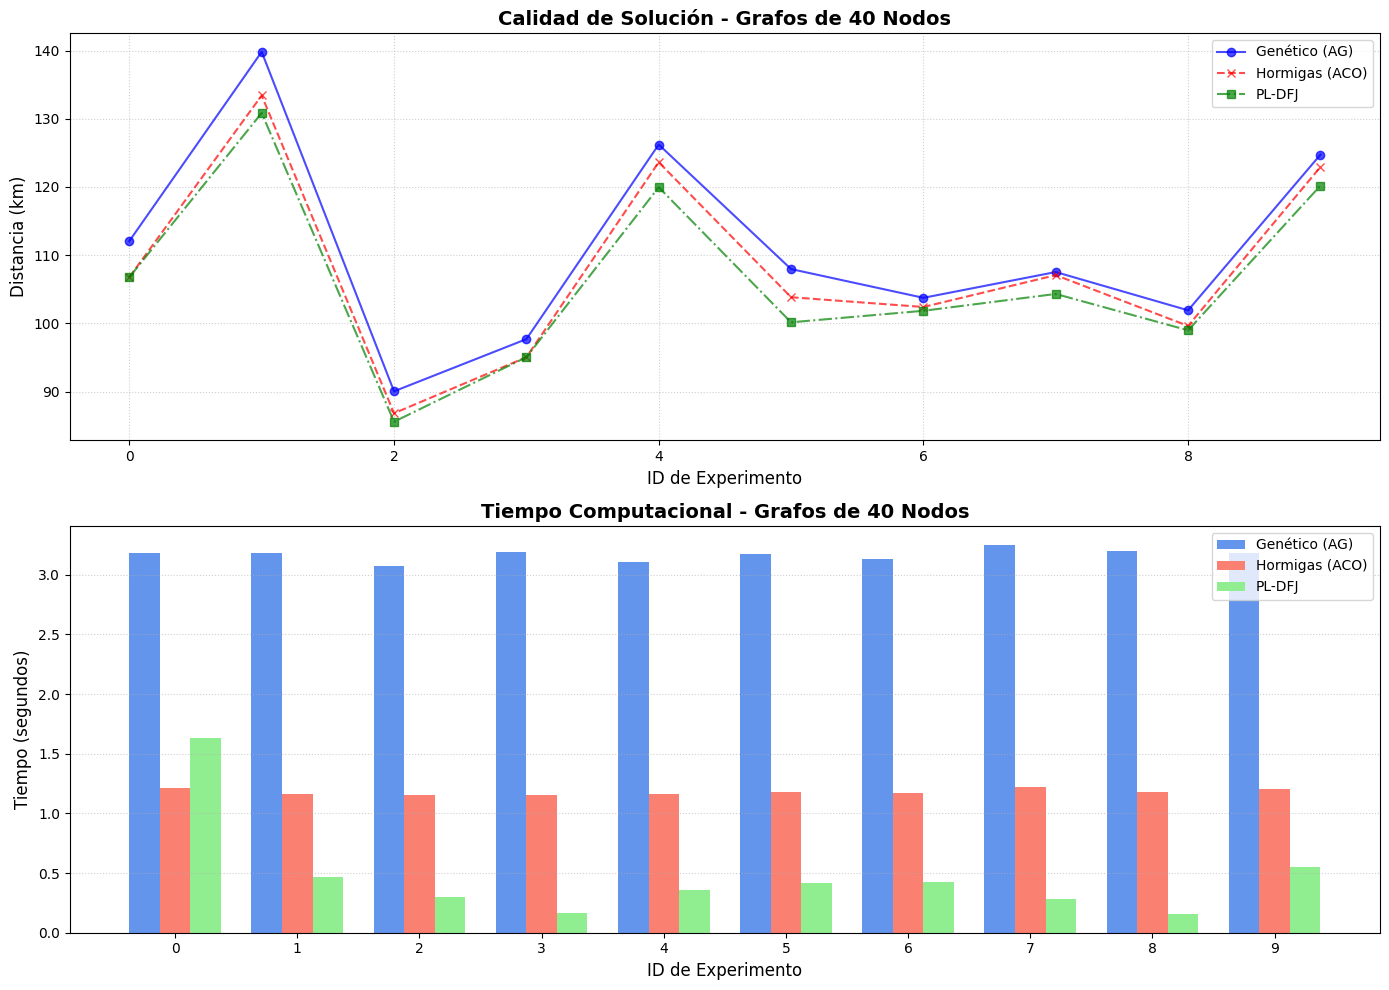


ESTADÍSTICAS - GRAFOS DE 40 NODOS
Distancia promedio AG:  111.18 km
Distancia promedio ACO: 108.16 km
Distancia promedio PL:  106.37 km

Tiempo promedio AG:  3.17 s
Tiempo promedio ACO: 1.18 s
Tiempo promedio PL:  0.48 s

✓ Reporte guardado: reports/comparacion_40nodos_con_PL.csv


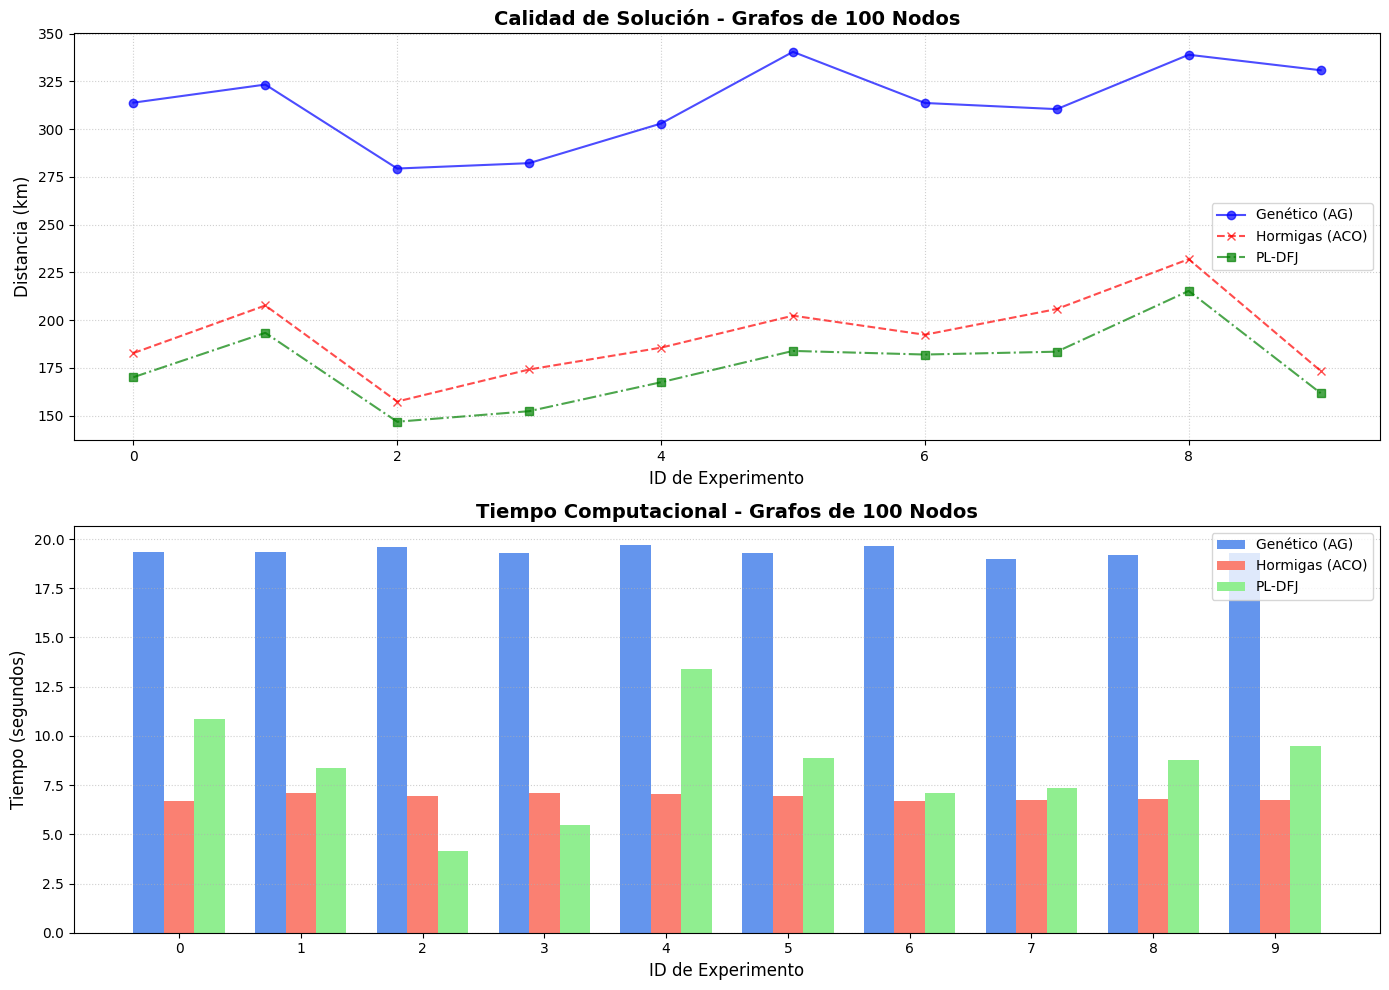


ESTADÍSTICAS - GRAFOS DE 100 NODOS
Distancia promedio AG:  313.67 km
Distancia promedio ACO: 191.38 km
Distancia promedio PL:  175.70 km

Tiempo promedio AG:  19.37 s
Tiempo promedio ACO: 6.89 s
Tiempo promedio PL:  8.38 s

✓ Reporte guardado: reports/comparacion_100nodos_con_PL.csv


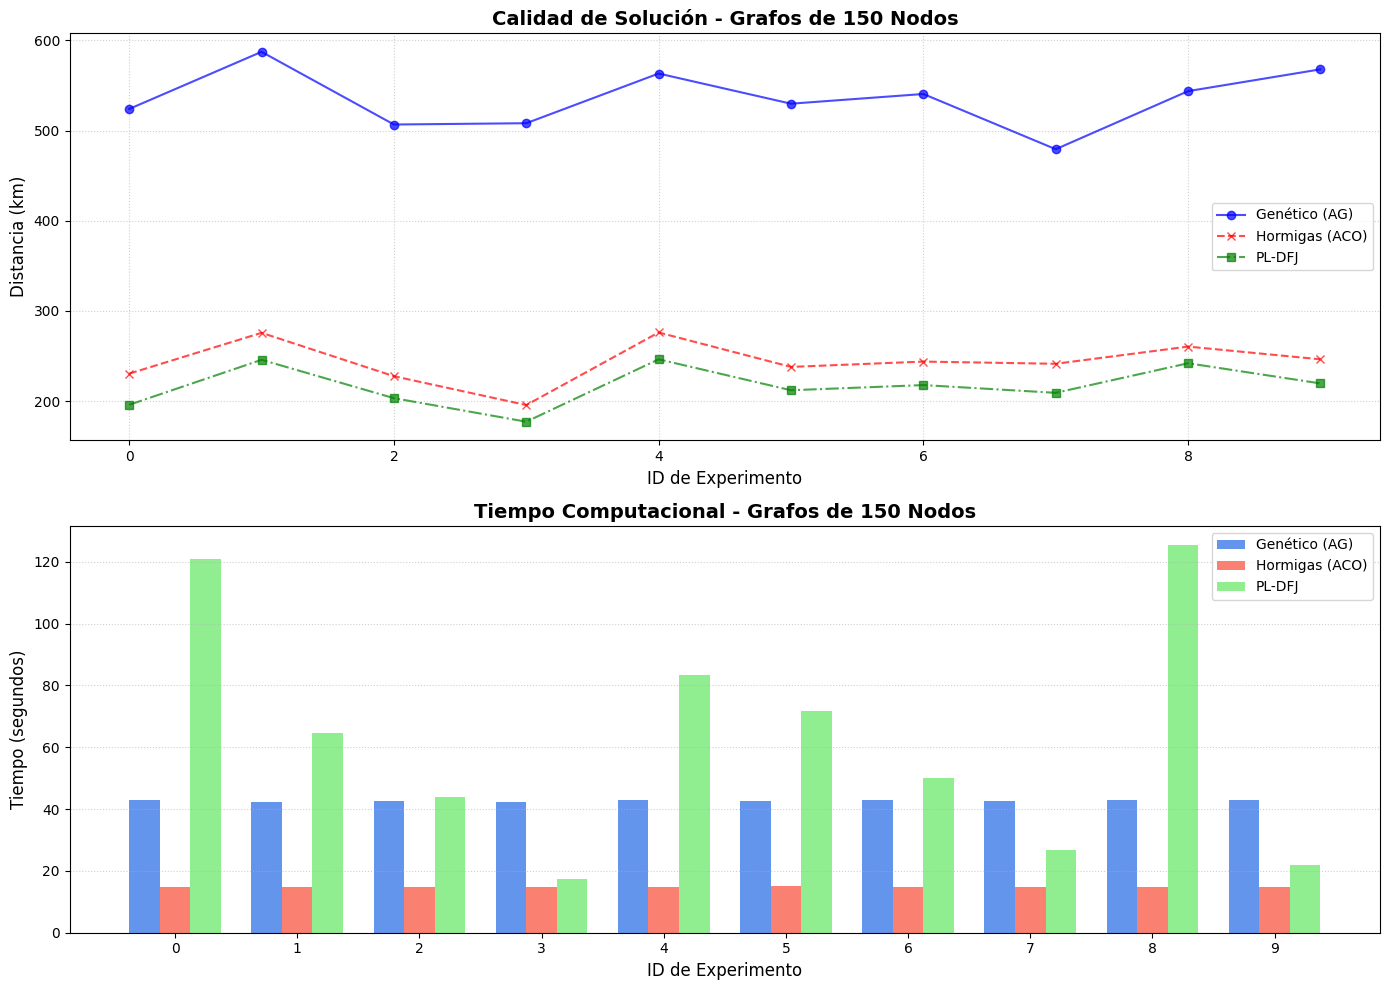


ESTADÍSTICAS - GRAFOS DE 150 NODOS
Distancia promedio AG:  535.10 km
Distancia promedio ACO: 243.50 km
Distancia promedio PL:  216.85 km

Tiempo promedio AG:  42.74 s
Tiempo promedio ACO: 14.87 s
Tiempo promedio PL:  62.60 s

✓ Reporte guardado: reports/comparacion_150nodos_con_PL.csv


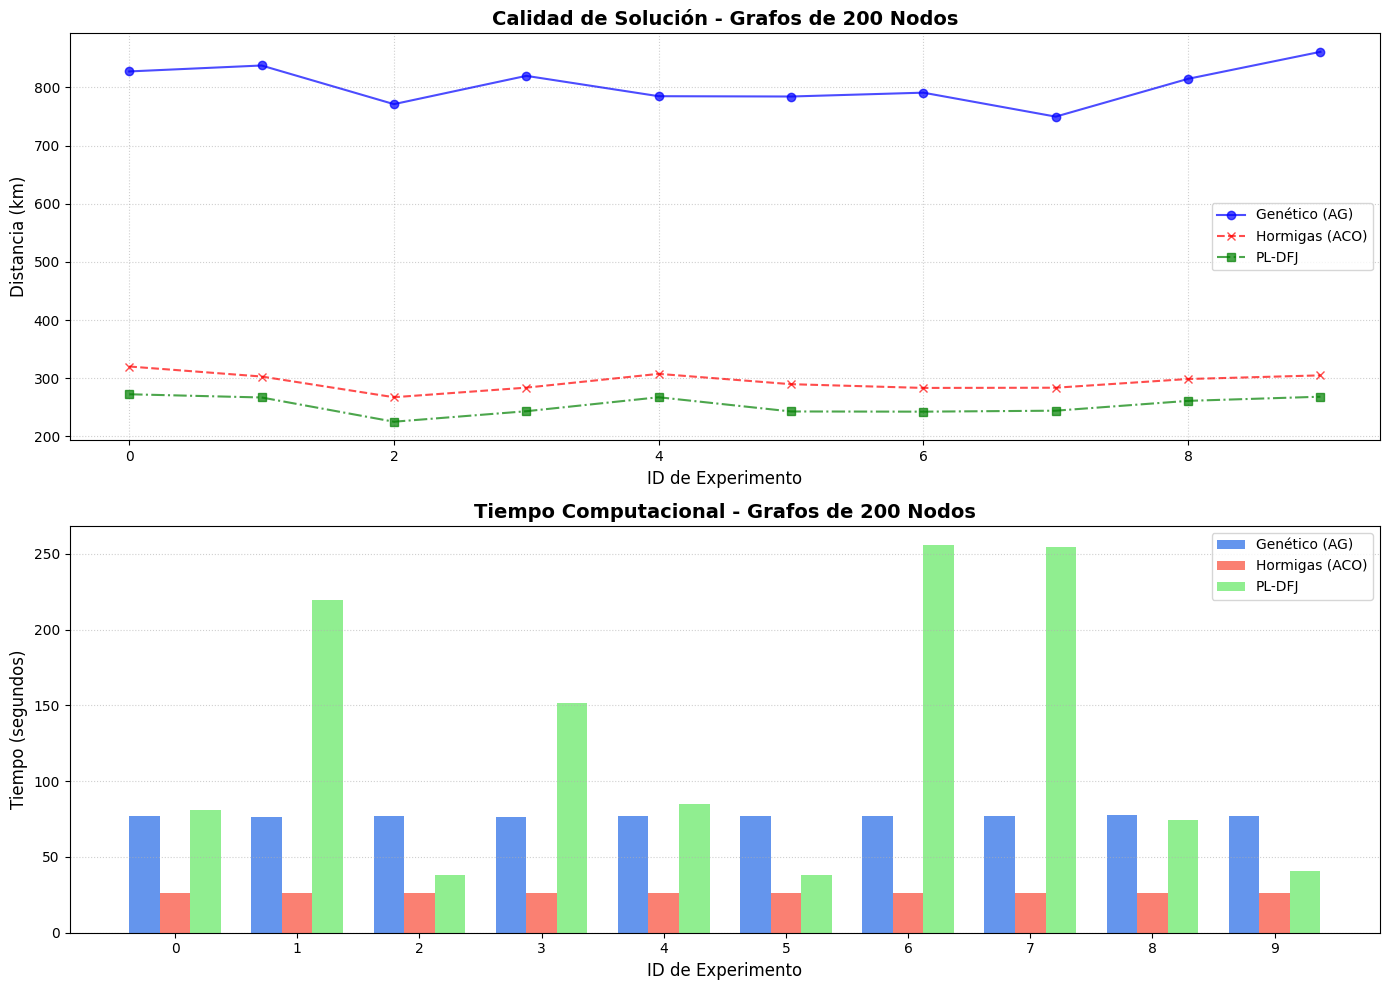


ESTADÍSTICAS - GRAFOS DE 200 NODOS
Distancia promedio AG:  804.19 km
Distancia promedio ACO: 294.11 km
Distancia promedio PL:  253.29 km

Tiempo promedio AG:  76.95 s
Tiempo promedio ACO: 26.18 s
Tiempo promedio PL:  123.81 s

✓ Reporte guardado: reports/comparacion_200nodos_con_PL.csv


In [17]:
def generar_comparacion_completa(lista_resultados, tam_grafo, incluir_pl=False):
    """
    Genera gráficas y tabla comparativa.
    Si incluir_pl=True, compara AG, ACO y PL-DFJ (3 métodos).
    Si incluir_pl=False, solo compara AG y ACO (2 métodos).
    """
    ids = [r['id_experimento'] for r in lista_resultados]
    
    costos_ag = [r.get('costo_total_AG', 0) for r in lista_resultados]
    costos_aco = [r.get('costo_total_ACO', 0) for r in lista_resultados]
    tiempos_ag = [r.get('tiempo_computo_AG', 0) for r in lista_resultados]
    tiempos_aco = [r.get('tiempo_computo_ACO', 0) for r in lista_resultados]
    
    if incluir_pl:
        costos_pl = [r.get('costo_total_PL', 0) for r in lista_resultados]
        tiempos_pl = [r.get('tiempo_computo_PL', 0) for r in lista_resultados]
    
    # Gráficas
    n_plots = 2 if incluir_pl else 2
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Calidad de solución
    ax1.plot(ids, costos_ag, label='Genético (AG)', color='blue', marker='o', linestyle='-', alpha=0.7)
    ax1.plot(ids, costos_aco, label='Hormigas (ACO)', color='red', marker='x', linestyle='--', alpha=0.7)
    if incluir_pl:
        ax1.plot(ids, costos_pl, label='PL-DFJ', color='green', marker='s', linestyle='-.', alpha=0.7)
    
    ax1.set_title(f'Calidad de Solución - Grafos de {tam_grafo} Nodos', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Distancia (km)', fontsize=12)
    ax1.set_xlabel('ID de Experimento', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # Tiempo computacional
    x = np.arange(len(ids))
    width = 0.25 if incluir_pl else 0.35
    
    rects1 = ax2.bar(x - width, tiempos_ag, width, label='Genético (AG)', color='cornflowerblue')
    rects2 = ax2.bar(x, tiempos_aco, width, label='Hormigas (ACO)', color='salmon')
    if incluir_pl:
        rects3 = ax2.bar(x + width, tiempos_pl, width, label='PL-DFJ', color='lightgreen')
    
    ax2.set_title(f'Tiempo Computacional - Grafos de {tam_grafo} Nodos', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Tiempo (segundos)', fontsize=12)
    ax2.set_xlabel('ID de Experimento', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(ids)
    ax2.legend()
    ax2.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(f'graphs/comparacion_{tam_grafo}nodos{"_con_PL" if incluir_pl else ""}.png', dpi=150)
    plt.show()
    
    # Tabla resumen
    datos_tabla = []
    for r in lista_resultados:
        fila = {
            'ID': r['id_experimento'],
            'Nodos': len(r['info_nodos']),
            'Dist_AG': round(r.get('costo_total_AG', 0), 2),
            'Dist_ACO': round(r.get('costo_total_ACO', 0), 2),
            'Tiempo_AG': round(r.get('tiempo_computo_AG', 0), 2),
            'Tiempo_ACO': round(r.get('tiempo_computo_ACO', 0), 2),
        }
        
        if incluir_pl:
            fila['Dist_PL'] = round(r.get('costo_total_PL', 0), 2)
            fila['Tiempo_PL'] = round(r.get('tiempo_computo_PL', 0), 2)
        
        datos_tabla.append(fila)
    
    df = pd.DataFrame(datos_tabla)
    
    # Estadísticas
    print(f"\n{'='*80}")
    print(f"ESTADÍSTICAS - GRAFOS DE {tam_grafo} NODOS")
    print(f"{'='*80}")
    print(f"Distancia promedio AG:  {np.mean(costos_ag):.2f} km")
    print(f"Distancia promedio ACO: {np.mean(costos_aco):.2f} km")
    if incluir_pl:
        print(f"Distancia promedio PL:  {np.mean(costos_pl):.2f} km")
    
    print(f"\nTiempo promedio AG:  {np.mean(tiempos_ag):.2f} s")
    print(f"Tiempo promedio ACO: {np.mean(tiempos_aco):.2f} s")
    if incluir_pl:
        print(f"Tiempo promedio PL:  {np.mean(tiempos_pl):.2f} s")
    
    # Guardar CSV
    csv_file = f'reports/comparacion_{tam_grafo}nodos{"_con_PL" if incluir_pl else ""}.csv'
    df.to_csv(csv_file, index=False)
    print(f"\n✓ Reporte guardado: {csv_file}")
    
    return df

# Generar reportes para cada tamaño
# La función detecta automáticamente si hay datos de PL disponibles
print("\n" + "="*80)
print("GENERANDO REPORTES COMPARATIVOS")
print("="*80)

# Detectar automáticamente si hay datos de PL
def tiene_datos_pl(lista_grafos):
    """Verifica si los grafos tienen resultados de PL-DFJ"""
    return any('ruta_optima_PL' in exp and exp['ruta_optima_PL'] is not None for exp in lista_grafos)

df_40 = generar_comparacion_completa(grafos_40, 40, incluir_pl=tiene_datos_pl(grafos_40))
df_100 = generar_comparacion_completa(grafos_100, 100, incluir_pl=tiene_datos_pl(grafos_100))
df_150 = generar_comparacion_completa(grafos_150, 150, incluir_pl=tiene_datos_pl(grafos_150))
df_200 = generar_comparacion_completa(grafos_200, 200, incluir_pl=tiene_datos_pl(grafos_200))

In [18]:
def visualizar_rutas_en_mapa(id_experimento, lista_resultados, incluir_pl=False):
    """Genera mapa interactivo con las rutas de los algoritmos"""
    datos = lista_resultados[id_experimento]
    nodos = datos['info_nodos']
    
    primer_id = list(nodos.keys())[0]
    centro_lat = nodos[primer_id]['lat']
    centro_lon = nodos[primer_id]['lon']
    
    m = folium.Map(location=[centro_lat, centro_lon], zoom_start=13)
    
    # Nodos
    fg_nodos = folium.FeatureGroup(name="Nodos")
    for nodo_id, info in nodos.items():
        folium.CircleMarker(
            location=[info['lat'], info['lon']],
            radius=5,
            color="black",
            fill=True,
            fill_color="white",
            popup=f"<b>ID: {nodo_id}</b><br>{info['nombre']}",
            tooltip=f"Nodo {nodo_id}"
        ).add_to(fg_nodos)
    fg_nodos.add_to(m)
    
    def obtener_coords(ruta):
        if not ruta:
            return []
        coords = [(nodos[nid]['lat'], nodos[nid]['lon']) for nid in ruta]
        coords.append(coords[0])  # Cerrar ciclo
        return coords
    
    # Ruta AG
    ruta_ag = datos.get('ruta_optima_AG', [])
    costo_ag = datos.get('costo_total_AG', 0)
    coords_ag = obtener_coords(ruta_ag)
    fg_ag = folium.FeatureGroup(name=f"AG ({costo_ag:.1f} km)")
    folium.PolyLine(coords_ag, color="blue", weight=4, opacity=0.6).add_to(fg_ag)
    fg_ag.add_to(m)
    
    # Ruta ACO
    ruta_aco = datos.get('ruta_optima_ACO', [])
    costo_aco = datos.get('costo_total_ACO', 0)
    coords_aco = obtener_coords(ruta_aco)
    fg_aco = folium.FeatureGroup(name=f"ACO ({costo_aco:.1f} km)")
    folium.PolyLine(coords_aco, color="red", weight=3, opacity=0.7, dash_array='10, 10').add_to(fg_aco)
    fg_aco.add_to(m)
    
    # Ruta PL si está disponible
    if incluir_pl:
        ruta_pl = datos.get('ruta_optima_PL', [])
        costo_pl = datos.get('costo_total_PL', 0)
        if ruta_pl:
            coords_pl = obtener_coords(ruta_pl)
            fg_pl = folium.FeatureGroup(name=f"PL-DFJ ({costo_pl:.1f} km)")
            folium.PolyLine(coords_pl, color="green", weight=3, opacity=0.7, dash_array='5, 5').add_to(fg_pl)
            fg_pl.add_to(m)
    
    folium.LayerControl(collapsed=False).add_to(m)
    
    return m

# Generar mapas de ejemplo
# La función detecta automáticamente si hay datos de PL disponibles
print("\nGenerando mapas interactivos...")
mapa_40 = visualizar_rutas_en_mapa(0, grafos_40, incluir_pl=tiene_datos_pl(grafos_40))
mapa_40.save("maps/comparacion_40nodos_exp0.html")

mapa_100 = visualizar_rutas_en_mapa(0, grafos_100, incluir_pl=tiene_datos_pl(grafos_100))
mapa_100.save("maps/comparacion_100nodos_exp0.html")

if tiene_datos_pl(grafos_150):
    mapa_150 = visualizar_rutas_en_mapa(0, grafos_150, incluir_pl=True)
    mapa_150.save("maps/comparacion_150nodos_exp0.html")

if tiene_datos_pl(grafos_200):
    mapa_200 = visualizar_rutas_en_mapa(0, grafos_200, incluir_pl=True)
    mapa_200.save("maps/comparacion_200nodos_exp0.html")

print("✓ Mapas guardados en maps/")


Generando mapas interactivos...
✓ Mapas guardados en maps/


## Método Exacto: PL-MTZ (una instancia de 40 nodos)

Este método garantiza encontrar la solución óptima global, pero es computacionalmente muy costoso.
Se ejecuta en una sola instancia para demostrar su capacidad.

In [21]:
print("="*80)
print("EJECUTANDO MÉTODO EXACTO: PL-MTZ")
print("="*80)
print("Este método garantiza la solución óptima global.")
print("⚠️ IMPORTANTE: Ahora ejecuta SIN LÍMITE DE TIEMPO hasta encontrar el óptimo.")
print("   Esto puede tardar desde 10 minutos hasta varias horas dependiendo del grafo.\n")

# Ejecutar en el primer grafo de 40 nodos
exp_demo = grafos_40[0]
lista_adyacencia, datos_nodos = procesar_grafo_separado(exp_demo)

pl_mtz = PL_MTZ_TSP(lista_adyacencia, datos_nodos)

inicio = time.time()
mejor_ruta, _, _ = pl_mtz.ejecutar()
tiempo_mtz = time.time() - inicio

print("\n" + "="*80)
print("RESULTADOS MTZ (ÓPTIMO GLOBAL):")
print("="*80)

if mejor_ruta is not None:
    exp_demo['ruta_optima_MTZ'] = pl_mtz.mejor_ruta
    exp_demo['costo_total_MTZ'] = pl_mtz.mejor_costo
    exp_demo['tiempo_computo_MTZ'] = round(tiempo_mtz, 4)
    
    print(f"✓ Solución óptima encontrada!")
    print(f"  Distancia óptima: {pl_mtz.mejor_costo:.4f} km")
    print(f"  Tiempo de cómputo: {tiempo_mtz:.2f}s ({tiempo_mtz/60:.2f} minutos)")
    print(f"  Ruta: {mejor_ruta[:15]}... (primeros 15 nodos)")
    
    # Comparar con otros métodos
    print(f"\n{'='*80}")
    print("COMPARACIÓN CON OTROS MÉTODOS (Experimento 0):")
    print("="*80)
    
    ag_dist = exp_demo.get('costo_total_AG', 0)
    aco_dist = exp_demo.get('costo_total_ACO', 0)
    pl_dist = exp_demo.get('costo_total_PL', 0)
    mtz_dist = pl_mtz.mejor_costo
    
    gap_ag = ((ag_dist - mtz_dist) / mtz_dist * 100) if mtz_dist > 0 else 0
    gap_aco = ((aco_dist - mtz_dist) / mtz_dist * 100) if mtz_dist > 0 else 0
    gap_pl = ((pl_dist - mtz_dist) / mtz_dist * 100) if mtz_dist > 0 else 0
    
    print(f"AG:      {ag_dist:.2f} km  (Gap: +{gap_ag:.2f}%)")
    print(f"ACO:     {aco_dist:.2f} km  (Gap: +{gap_aco:.2f}%)")
    print(f"PL-DFJ:  {pl_dist:.2f} km  (Gap: +{gap_pl:.2f}%)")
    print(f"MTZ:     {mtz_dist:.2f} km  (ÓPTIMO)")
    
    ag_tiempo = exp_demo.get('tiempo_computo_AG', 0)
    aco_tiempo = exp_demo.get('tiempo_computo_ACO', 0)
    pl_tiempo = exp_demo.get('tiempo_computo_PL', 0)
    
    print(f"\nSPEEDUP (vs MTZ):")
    print(f"AG:      {tiempo_mtz/ag_tiempo:.1f}x más rápido")
    print(f"ACO:     {tiempo_mtz/aco_tiempo:.1f}x más rápido")
    print(f"PL-DFJ:  {tiempo_mtz/pl_tiempo:.1f}x más rápido")
else:
    print(f"✗ No se encontró solución en el tiempo límite")
    print(f"  Tiempo transcurrido: {tiempo_mtz:.2f}s")

EJECUTANDO MÉTODO EXACTO: PL-MTZ
Este método garantiza la solución óptima global.
⚠️ IMPORTANTE: Ahora ejecuta SIN LÍMITE DE TIEMPO hasta encontrar el óptimo.
   Esto puede tardar desde 10 minutos hasta varias horas dependiendo del grafo.

Resolviendo modelo MTZ (sin límite de tiempo)...
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/anaconda3/envs/MA2015/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/8m/l4ygm3md25s64dm62dskw7_h0000gn/T/5de180bc8ef6405a8a20afb96e8507c3-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/l4ygm3md25s64dm62dskw7_h0000gn/T/5de180bc8ef6405a8a20afb96e8507c3-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1568 COLUMNS
At line 13816 RHS
At line 15380 BOUNDS
At line 16981 ENDATA
Problem MODEL has 1563 rows, 1600 columns and 7567 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elaps

## Resumen final

El notebook ha completado la comparación de 4 algoritmos para resolver el TSP:

1. **Algoritmo Genético (AG)**: Metaheurística evolutiva con Edge Recombination Crossover
2. **Colonia de Hormigas (ACO)**: Metaheurística basada en feromonas
3. **Programación Lineal DFJ**: Método iterativo con eliminación de subtours
4. **Programación Lineal MTZ**: Método exacto que garantiza el óptimo global

### Archivos generados:

**Subdirectorio `maps/`:**
- `comparacion_40nodos_exp0.html`
- `comparacion_100nodos_exp0.html`

**Subdirectorio `reports/`:**
- `comparacion_40nodos_con_PL.csv`
- `comparacion_100nodos.csv`
- `comparacion_150nodos.csv`
- `comparacion_200nodos.csv`

**Subdirectorio `graphs/`:**
- `comparacion_40nodos_con_PL.png`
- `comparacion_100nodos.png`
- `comparacion_150nodos.png`
- `comparacion_200nodos.png`

---

## Instrucciones de ejecución

Este notebook está diseñado para ejecutarse **secuencialmente de arriba hacia abajo**. La estructura es:

1. **Configuración inicial**: Importar librerías y crear directorios de salida
2. **Funciones auxiliares**: Construcción de grafos y procesamiento de datos
3. **Clases de algoritmos**: Definición de GA_TSP, ACO_TSP, PL_TSP, PL_MTZ_TSP
4. **Generación de instancias**: Crear grafos de 40, 100, 150 y 200 nodos
5. **Fase 1 - AG y ACO**: Ejecutar métodos heurísticos en todas las instancias
6. **Fase 2 - PL-DFJ**: Ejecutar método iterativo en grafos de 40 nodos
7. **Análisis**: Generar reportes comparativos, gráficas y mapas
8. **MTZ (opcional)**: Ejecutar método exacto en una instancia para benchmark

**Nota**: El método MTZ puede tardar >10 minutos. Se ejecuta al final para no bloquear el flujo principal.